<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section05_Computer_Vision/Chapter00_Convolutional_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**COMPUTER VISION**

From the moment a newborn opens its eyes, a lifelong process begins — the art of seeing and understanding the world.  
At first, everything is just brightness, darkness, and shapes. Slowly, the brain starts finding patterns. A blur becomes a face. A familiar face becomes “mother.” A new tone of light becomes “day” or “night.”  

As the days pass, vision helps the baby *connect* with reality:  
- Recognizing the gentle smile of a parent.  
- Spotting the bright red color of a favorite toy.  
- Following the movements of a cartoon character on a screen.  
- Distinguishing between fruits, animals, and people.  

By the time the child starts school, vision has become a silent teacher:  
- Reading shapes of letters and numbers.  
- Identifying friends from a distance with just a glance.  
- Predicting a potential danger from a very fast car, a venomous insect, or a high cliff.  

You can see how vision is already helping the child survive and have a better understanding of the world around him. Vision is one of evolution’s greatest tools for survival and adaptation.  

Now imagine building a machine that thinks and helps like a human — but without vision. The machine could calculate, sort data, and follow rules… but it wouldn’t *see* the world it’s working in.  

While giving machines the gift of vision changes everything:  
* **Safety**: Cars that detect pedestrians before accidents happen.
* **Medicine**: AI systems that identify tumors in scans faster than doctors.
* **Exploration**: Robots that navigate unknown planets or the depths of the ocean.
* **Everyday convenience**: Phones that unlock with a glance and apps that translate signs instantly.
* **Agriculture**: Drones and sensors that monitor crop health and detect pests early to improve yields.
* **Security**: Surveillance systems that recognize suspicious behavior or unauthorized entry in real time.
* **Accessibility**: Tools that help visually impaired people “see” by describing surroundings or reading text aloud.
* **Sports Analytics**: Cameras and AI analyzing player movements to improve training and prevent injuries.
* **Art and Creativity**: Software that helps create digital art or restore old images by analyzing patterns and colors.
* **Disaster Response**: Drones and robots surveying damage and locating survivors in dangerous areas.

**Computer vision** is not just about making machines smarter — it’s about giving them the ability to perceive and understand the world visually, just as we do.  
And when machines can see, they can protect us, guide us, and make our lives a lot easier in ways we’ve only begun to imagine.

---

## **Timeline**

The dream of giving machines the ability to “see” has been around since the early days of computing — but it has always been a difficult and costly challenge.

In the earliest attempts, computer vision relied heavily on **manual feature engineering** (something we’ve already discussed in `Section00-Chapter01`). Engineers would painstakingly design algorithms to extract specific properties from images — color histograms, edge patterns, brightness distributions — hoping these handcrafted features would be enough for a machine to understand what it was looking at.  
This process was **subjective**, **time-consuming**, and often **inefficient**: what worked for one dataset could completely fail on another. For example:
- Classifying fruits simply by their dominant color.  
- Identifying landscapes based on the tone of brightness.  
- Matching objects by predefined shape descriptors.  

Until early 2010s, most of the research was focused on **improving feature extraction methods**, while the actual classification models were relatively simple. The bottleneck wasn’t in training a model — it was in finding the “right” features for it to learn from. Neural networks existed, but they played a very minor role.

Then in **2012**, a turning point in computer vision history took place. A groundbreaking paper introduced **AlexNet**, a deep neural network with 8 layers (we will discuss its architecture in later chapters of this section), that completely shattered previous records in the ImageNet competition.  
Before AlexNet, even the best models struggled to get below **26%** error for decades, progress had been painfully slow — improvements came in fractions of a percent. But AlexNet achieved an astonishing **16%** error, a leap so dramatic that it made researchers leave decades of handcrafted feature engineering almost overnight.  

From that moment on, the field of computer vision began to revolve around **deep learning**, forever changing how machines learn to see.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/sota.png" width="500">
</div>

**Image Credit:** [Original Website](https://www.mshowto.org/deep-learning-ve-computer-vision.html)


#**CONVOLUTIONAL NEURAL NETWORKS**

In the previous section, we worked with the MNIST dataset using a **dense (fully connected) neural network** — a neuron in a layer is connected to all the neurons in the next layer — that wasn’t even very deep, yet it gave us an excellent test accuracy and very low training loss. We even went the extra mile — optimizing it, regularizing it, and ensuring it was performing at its best.

So a fair question to ask now is:  
**Why don’t we just keep using those networks for *any* image classification task?**  
Why are we about to study a whole new architecture of neural networks?

---

### **The Core Problem With Dense Neural Networks**
When we use a fully connected network for images, we’re essentially **ignoring the spatial relationships** in the data.  

In a fully connected setup, every neuron in one layer connects to every neuron in the next layer. This works great for **tabular data** where features are often **independent** from each other.  
For example, in a diabetes dataset, the `Age` column has nothing to do with the `Gender` column — so it makes sense for the network to process all features separately.

But with **image data**, things are different. Here, each feature (pixel) has a **strong relationship** with its neighboring pixels. It doesn't transfer such an important information by its own. A pixel in one part of the image gains meaning only when considered alongside those around it. So there is no need to pass each of the pixels to a unique neuron. In the meantime, when we **flatten** an image into a long 1D array, we destroy that neighborhood relationship completely.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/flattened.png" width="500">
</div>

Flattening means the network no longer looks for **patterns in a region of the image** — instead, it searches for patterns in rows of pixel values with no idea where they came from. The rows are also passed to different neurons. So we're basically asking the neurons to guess the image by a pixel of "red" color.
This is a huge problem because the spatial arrangement of pixels is essential to recognizing shapes, edges, textures, and objects.

---

### **The Parameter Explosion**
Fully connected layers are parameter-hungry. Let’s put this into perspective:  

If we have a grayscale image with a resolution of **1000×1000 pixels**, that’s **1,000,000 input values**. If our first hidden layer has **1,000 neurons**, then:

- Number of weights = `1,000,000 × 1,000` = **1,000,000,000 parameters** (1 billion!)  
- Plus **1,000 bias terms**

That’s for **just one layer**.

This leads to:
- **Massive overfitting** — the network will memorize training data instead of generalizing.  
- **Insane memory usage** — storing billions of parameters is no small task.  
- **Huge computational cost** — training will be painfully slow or impossible without massive hardware resources.

---

### **The Invariance Problem**
Even if we set aside overfitting and computational limits, fully connected networks still lack an essential property for vision tasks: **invariance**.

Here’s what happens:  
Suppose we train a model to recognize strawberries using a dataset where all strawberries are perfectly centered in the image. The model will learn to associate “center pixels” with the concept of a strawberry.  

Now, if we give it a picture of a strawberry in the **corner** of the image, the model will likely fail to recognize it. Why? Because different parts of the flattened array are being activated — parts that weren’t associated with strawberries during training.

This isn’t just about position:
- If the strawberry is **rotated slightly**, the model might fail again.  
- If the strawberry is **larger or smaller** than what the model has seen, it might fail again.  

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/invariance.png" width="500">
</div>

To make a fully connected model invariant to such changes, we would have to train it on **huge datasets** containing strawberries at:
- Top-right, top-left, bottom-right, bottom-left corners  
- Various sizes  
- Various angles  
- Different lighting conditions  

And even then, one unusual color change might break the model.

This limitation — where the model fails to recognize an object if it’s shifted or scaled — is the lack of **shift invariance** or **scale invariance**.

Fully connected layers don’t have these abilities naturally. They must “learn” them entirely from the data, which is inefficient.

---

### **Equivariance vs. Invariance**
Now, we don’t want **complete invariance** either. Position, scale, and rotation most of the times matter.  

For example:
- In medical imaging, the **location** of an abnormality can be as important as the abnormality itself.
- In a person's image, it's to important to understand if he/she's facing up/down/left/right.
- In a garden's images, the **size** of each of the fruits conveys essential information about how healthy they are.

What we want is a **balance**:
- **Invariance** for changes that don’t affect meaning (e.g., a strawberry anywhere in the image is still a strawberry).  
- **Equivariance** for changes where position, size, or orientation do matter (e.g., a hemorrhage's position in the brain MRI images is important).

---

### **Why We Need a New Architecture**
Fully connected networks fail to strike this balance. They:
- Destroy spatial relationships by flattening.  
- Require absurd numbers of parameters for large images.  
- Struggle with invariance without massive datasets.  
- Have no built-in bias toward local structure in images.

This is where **Convolutional Neural Networks (CNNs)** come in. They introduce an **inductive bias** that makes the model focus on **local pixel neighborhoods**, reuse learned patterns across the image, and drastically reduce the number of parameters — all while naturally improving invariance and preserving important spatial structure.

---

##**Layers in a CNN**

1. **Convolutional Layers** – Responsible for finding simple patterns from small local regions of the image (often 3×3 pixels).
2. **Pooling Layers** – Reduce the number of parameters significantly, helping to avoid overfitting and making the network faster.
3. **Fully Connected Layers** – After almost all the important features have been extracted automatically (**NOT** manually), these layers learn which features correspond to which classes.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/layers.png" width="600">
  <h5>Figure: Different Layers of A CNN</h5>
</div>

**Image Credit**: [Original Website](https://www.freecodecamp.org/news/an-intuitive-guide-to-convolutional-neural-networks-260c2de0a050/)

## **Convolutional Layer**

In a convolutional layer, we use a **filter** (also called a *kernel*), usually of size 3×3 or 5×5, which slides over different local regions of the image matrix.

This kernel is initialized with random weights and acts like a pattern detector. For example, suppose we want to detect an eye in a 28×28×3 image (28 pixels high, 28 pixels wide, and 3 RGB color channels) using a 3×3×3 kernel.

The kernel might look like this:

$$
K_{3×3} = \begin{pmatrix} 1 & 1 & 1 \\
  1 & -1 & 1 \\
  1 & 1 & 1 \\
\end{pmatrix}
$$

What does it do?

* This kernel looks for a region with a dark center surrounded by lighter pixels.
* If the center pixel is dark (near zero) and the surrounding pixels are bright, multiplying the center by -1 will yield a strong response (because -1 × 0 is still 0, but surrounded by bright pixels that give positive values, the sum will be large).
* If the center is bright, multiplying it by -1 will drastically reduce the overall sum, making it unlikely to activate.

When we **convolve** this kernel over the entire image, it will *fire* (produce high activation) anywhere it detects this dark-center/light-surround pattern — effectively detecting “eyes” anywhere in the image. This gives **shift invariance** — it doesn’t matter where the eye appears, its output will be a big number in that part. It also is **shift equivariant** because it obviously conserves the position of each of the eyes relative to the others.

And the parameter count is tiny:

* 9 weight values + 1 bias term = **10 parameters total**.
  Compare that to a fully connected layer:
* If we flattened our 28×28 image into a 784-length vector and connected it to just 1 neuron, we’d need **784 weights + 1 bias**. For more neurons, the number grows explosively, all along with its other disadvantages.

We can now stack many kernels — e.g., an eye detector, a nose detector, a mouth detector. A higher layer could connect to all three and fire only when all are activated, enabling **face detection** anywhere in the image, at any scale, with far fewer parameters than a fully connected approach.

**Weight sharing** is a key feature of convolutional layers that makes CNNs efficient and powerful. By using the same filter weights across all positions of the input image, a single filter learns to detect a specific pattern (e.g., edges or textures) everywhere in the image. This reduces the number of parameters compared to fully connected layers, preventing overfitting and making training faster. For example, a 3x3 filter applied to a 28x28 image uses only 9 weights (plus a bias) instead of 784 for a dense layer, while still capturing spatial features effectively.

---

### **Backpropagation in Convolutional Layers**

Backpropagation works the same way as in fully connected layers:

* Compute the loss gradient with respect to the output.
* Pass the gradient back through the convolution operation to update the kernel weights.
* Because kernels are reused across the image, the gradient contributions from all positions are summed before updating each weight.

---

###**Features in Conv. Layers**

We talked about a manually initialized kernel for eye detection. It’s very important to understand that **in a real convolutional layer, this does not happen**.  

All the weights in convolutional layers are initialized **randomly**, just like we did in fully connected layers. When training starts, the loss computed in the last fully connected layers is backpropagated through the network.  
These gradients flow backward and update the weights in the convolutional layers gradually, shifting them to detect the most useful features that minimize the overall loss.  

One of the most fascinating points is that the features learned by CNNs often **don’t make intuitive sense to us humans**.  
Even though we might imagine neurons “looking for” eyes, mouths, or ears, the reality is that many learned features look completely abstract and meaningless to us — but they carry important information to the network.  

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/alexnet_features.png" width="300">
  <h5>Figure: Filters in the first layer of AlexNet, ordered by their CAR importance index.</h5>
</div>

At this stage in computer science, we have unlocked an incredible power:  
Machines are discovering patterns and algorithms that **are not easily explainable or even understandable by humans**.  

If I asked you to write a mathematical algorithm to check whether some points lie on a line, you’d probably say:  
> Create a linear equation using two points’ coordinates and check if the others satisfy it.  

That algorithm is quite explainable and easy to understand. If I asked whether the points form a circle, you’d still be able to write a formula, albeit more complicated.  

But if I asked you to write an algorithm to determine whether a set of points forms a brain tumor shape, you’d almost certainly say:  
> I can’t. There’s no interpretable mathematical description for this problem.  

That’s why, instead of trying to handcraft every single pattern mathematically,  
we teach machines to **see and think in ways that are natural for them**.  

It’s impossible to write explicit math for every image pattern, but CNNs learn to extract features and representations that work best for the task — even if those features are **beyond human interpretability**.

This is the new frontier of artificial intelligence, where machines unlock insights in data that humans can barely describe.

---

### **Channels**
A convolutional layer handles multiple **input channels** (e.g., 3 for RGB images) by applying a separate filter for each channel. Each filter is a small grid (e.g., 3x3) that slides over its corresponding channel, producing a feature map by computing weighted sums. The layer combines these maps (summing across channels) to create one output map per filter. By using multiple filters (e.g., 8), the layer generates multiple output channels, each capturing a unique pattern—like edges, textures, or shapes—learned during training. More filters allow the network to detect diverse features, but too many can increase computation and risk overfitting.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/channels.gif" width="400">
  <h6>Figure: Convolving over 3 channeled input with 2 filters</h6>
</div>

**Image Credit**: [Original Website](https://www.freecodecamp.org/news/an-intuitive-guide-to-convolutional-neural-networks-260c2de0a050/)

### **Padding**
Padding adds zeros around the input image to control the output size after convolution. Without padding, the output shrinks because the filter can’t cover border pixels fully. For example, a 3x3 filter on a 28x28 image without padding reduces the output to 26x26. Padding (e.g., 1 pixel) preserves the original size (28x28) by allowing the filter to slide over the borders. The output shape is calculated as:

$$
\text{output}_h = \left\lfloor \frac{\text{input}_h + 2 \cdot \text{padding} - \text{filter}_h}{\text{stride}} \right\rfloor + 1, \quad \text{output}_w = \left\lfloor \frac{\text{input}_w + 2 \cdot \text{padding} - \text{filter}_w}{\text{stride}} \right\rfloor + 1
$$

Padding ensures spatial information is retained and supports deeper networks by preventing excessive size reduction.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/padding.gif" width="300">
  <h6>Figure: Padding keeps output size the same as input size</h6>
</div>

**Image Credit**: [Original Website](https://www.freecodecamp.org/news/an-intuitive-guide-to-convolutional-neural-networks-260c2de0a050/)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist, fashion_mnist
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
class Layer:
    def __init__(self):
        self.inp = None
        self.out = None

    def forward(self, inp: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def backward(self, up_grad: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def step(self, lr: float) -> None:
        pass

class Conv2D(Layer):
    def __init__(self, input_channels: int, num_filters: int, filter_size: int = 3, stride: int = 1, padding: int = 0):
        np.random.seed(42)
        super().__init__()
        self.input_channels = input_channels
        self.num_filters = num_filters
        self.filter_size = filter_size
        self.stride = stride
        self.padding = padding

        self.filters = np.random.randn(num_filters, input_channels, filter_size, filter_size) * np.sqrt(2 / (input_channels * filter_size ** 2))
        self.biases = np.zeros((num_filters, 1))

    def forward(self, X):
        self.inp = X
        batch_size, channels, height, width = X.shape

        # Padding the input
        self.X_padded = np.pad(X, ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')
        out_h = (height + 2 * self.padding - self.filter_size) // self.stride + 1
        out_w = (width + 2 * self.padding - self.filter_size) // self.stride + 1
        self.out = np.zeros((batch_size, self.num_filters, out_h, out_w))

        # Convolution operation
        for i in range(out_h):
            for j in range(out_w):
                region = self.X_padded[:, :, i*self.stride:i*self.stride+self.filter_size, j*self.stride:j*self.stride+self.filter_size]
                self.out[:, :, i, j] = np.tensordot(region, self.filters, axes=([1, 2, 3], [1, 2, 3])) + self.biases.T

        return self.out

    def backward(self, up_grad):
        batch_size, input_channels, height, width = self.inp.shape
        _, _, out_h, out_w = up_grad.shape

        self.d_filters = np.zeros_like(self.filters)
        self.d_biases = np.sum(up_grad, axis=(0, 2, 3), keepdims=True).reshape(self.num_filters, 1)
        down_grad = np.zeros_like(self.X_padded)

        for i in range(out_h):
            for j in range(out_w):
                region = self.X_padded[:, :, i*self.stride:i*self.stride+self.filter_size, j*self.stride:j*self.stride+self.filter_size]
                self.d_filters += np.tensordot(up_grad[:, :, i, j], region, axes=([0], [0])) # Compute weight gradient
                for n in range(batch_size):
                    down_grad[n, :, i*self.stride:i*self.stride+self.filter_size, j*self.stride:j*self.stride+self.filter_size] += np.tensordot(self.filters, up_grad[n, :, i, j], axes=(0, 0))

        # Remove padding if applied
        if self.padding > 0:
            down_grad = down_grad[:, :, self.padding:-self.padding, self.padding:-self.padding]
        return down_grad

    def step(self, lr):
        self.filters -= lr * self.d_filters
        self.biases -= lr * self.d_biases

In [ ]:
# Simulate an input matrix (image)
arr = np.arange(1, 21).reshape(1, 1, 4, 5)
print(f'Original Array {arr.shape} --> 1 image, 1 channel, 4 rows, 5 columns:\n{arr}\n', '-'*35)

# Create a convolutional layer and pad the input
conv = Conv2D(input_channels = 1, num_filters = 1, filter_size = 3, stride = 1, padding = 1)

# Manipulate the filter of the conv
conv.filters = np.ones_like(conv.filters)
print(f'Manipulated (Manually) Filter {conv.filters.shape}:\n{conv.filters}\n', '-'*35)

# Convolve The Filter Over The Image
convolved_arr = conv.forward(arr)
padded_arr = conv.X_padded
print(f'Padded Array {padded_arr.shape}:\n{padded_arr}\n', '-'*35)
print(f"Convolved Array {convolved_arr.shape} --> Notice How Image's Shape Didn't Change (Due To Padding):\n{convolved_arr}\n")

Original Array (1, 1, 4, 5) --> 1 image, 1 channel, 4 rows, 5 columns:
[[[[ 1  2  3  4  5]
   [ 6  7  8  9 10]
   [11 12 13 14 15]
   [16 17 18 19 20]]]]
 -----------------------------------
Manipulated (Manually) Filter (1, 1, 3, 3):
[[[[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]]]
 -----------------------------------
Padded Array (1, 1, 6, 7):
[[[[ 0  0  0  0  0  0  0]
   [ 0  1  2  3  4  5  0]
   [ 0  6  7  8  9 10  0]
   [ 0 11 12 13 14 15  0]
   [ 0 16 17 18 19 20  0]
   [ 0  0  0  0  0  0  0]]]]
 -----------------------------------
Convolved Array (1, 1, 4, 5) --> Notice How Image's Shape Didn't Change (Due To Padding):
[[[[ 16.  27.  33.  39.  28.]
   [ 39.  63.  72.  81.  57.]
   [ 69. 108. 117. 126.  87.]
   [ 56.  87.  93.  99.  68.]]]]



In [ ]:
# A filter that only maps the channel 0 (red) of the input image
red_filter = np.zeros((3, 3, 3, 3))
red_filter[0, 0, :, :] = np.ones((3, 3)) / 9

# A filter that only maps the channel 1 (green) of the input image
green_filter = np.zeros((3, 3, 3, 3))
green_filter[1, 1, :, :] = np.ones((3, 3)) / 9

# A filter that only maps the channel 2 (blue) of the input image
blue_filter = np.zeros((3, 3, 3, 3))
blue_filter[2, 2, :, :] = np.ones((3, 3)) / 9

# A filter that sums the maps above resulting in an RGB image filter
rgb_filter = red_filter + green_filter + blue_filter

# Black & White filter: Converts to grayscale by averaging RGB channels
bw_filter = np.ones((3, 3, 3, 3)) / 27

# Gaussian Blur filter: Smooths image using a 3x3 Gaussian kernel
gaussian_blur = np.array([[1, 2, 1],
                         [2, 4, 2],
                         [1, 2, 1]]) / 16
blur_filter = np.zeros((3, 3, 3, 3))
for i in range(3):  # Apply to each output and input channel
    blur_filter[i, i, :, :] = gaussian_blur

# Edge Detection filter: Highlights edges using a Sobel-like kernel
edge_filter = np.zeros((3, 3, 3, 3))
edge_kernel = np.array([[-1, -1, -1],
                        [-1,  8, -1],
                        [-1, -1, -1]]) * 5
for i in range(3):
    edge_filter[i, i, :, :] = edge_kernel

# Sharpen filter: Enhances details by amplifying central pixels
sharpen_filter = np.zeros((3, 3, 3, 3))
sharpen_kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]]) * 1.5
for i in range(3):
    sharpen_filter[i, i, :, :] = sharpen_kernel

filters = {
    'Red Filter': red_filter,
    'Green Filter': green_filter,
    'Blue Filter': blue_filter,
    'RGB Filter': rgb_filter,
    'B&W Filter': bw_filter,
    'Blur Filter': blur_filter,
    'Edge Filter': edge_filter,
    'Sharpen Filter': sharpen_filter
}

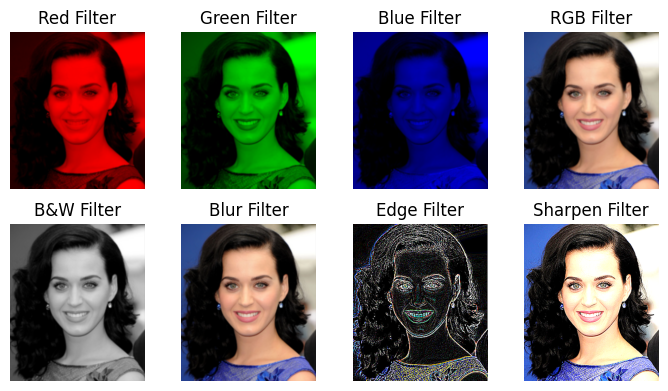

In [ ]:
import requests
from PIL import Image
from io import BytesIO

# URL of the image
url = "https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S02_C01/faces/face1.png"

# Download image
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Convert to NumPy array & Normalize
img_arr = np.array(img).astype('float32') / 255.0
img_arr = img_arr.transpose(2, 0, 1)
img_arr = img_arr.reshape(1, 3, 350, 300)

# Create subplots
fig, axes = plt.subplots(2, len(filters) // 2, figsize=(7, 4))
axes = axes.flatten() if len(filters) > 1 else [axes]

# Apply each filter
for ax, (title, filter) in zip(axes, filters.items()):
    conv = Conv2D(input_channels=3, num_filters=3)
    conv.filters = filter  # Shape to (3, 3, 3, 3)
    output = conv.forward(img_arr)  # Shape: (1, 3, 350, 300)
    output = np.clip(output, 0, 1)
    ax.imshow(output[0].transpose(1, 2, 0))  # Shape: (350, 300, 3)
    ax.axis('off')
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

## **Pooling Layer**

Imagine searching for your best friend in a crowded festival. You don’t need to memorize every face—just spot their bright red hat or loud laugh to know they’re there. That’s what a pooling layer does in a neural network! After a convolutional layer finds patterns like edges or shapes (say, eyes in a photo), it creates detailed feature maps—think of them as a huge, crowded map of clues. But this map is too big, slowing everything down. A pooling layer steps in to **summarize** it, shrinking the size while keeping the key clues, making the network faster and more focused.

Why do we need this? Convolution gives us tons of data—picture a 28x28 image turning into a massive stack of feature maps. This makes training slow, eats up memory, and risks the network obsessing over exact pixel positions (like failing to spot your friend if their hat shifts slightly). Pooling solves this by **downsampling** the maps, cutting computation (e.g., halving the size reduces parameters by a quarter for later layers), and making the network okay with small shifts in patterns—like recognizing an eye even if it moves a bit.

---

### **Types of Pooling**
1. **Max Pooling**: Looks at a small patch (like 2x2) and picks the **strongest clue**—the highest value.
2. **Average Pooling**: Takes the **average value** of the patch by blending all values. Useful for softer patterns but less common since it can blur important clues.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/pooling.png" width="500">
  <h6>Figure: Max pooling & Average (mean) pooling</h6>
</div>

**Image Credit:** [Original Website](https://www.researchgate.net/figure/Example-of-max-pooling-and-average-pooling-operations-In-this-example-a-4x4-image-is_fig4_332092821)

### **Window and Stride**
Think of a 2x2 window sliding over the feature map (matrix) with a stride of 2 (equal to the window size). Unlike convolution, where we overlap to catch every detail, pooling avoids overlap to focus on **reducing size**. We just want to know if a pattern exists in a region, not its exact pixel spot. That's how a 28x28 map becomes 14x14, shrinking data to a quarter while keeping the main ideas.

> 📌 **Example in Action**: Remember our "eye detector" convolution on a 28x28 image? It highlighted bright spots for eyes. A 2x2 max pooling with stride 2 picks the brightest spot in each patch, keeping eye locations but shrinking to 14x14. If the eye shifts slightly, pooling still catches it, like spotting your friend’s hat even if they turn their head.

---

### **Backpropagation in Pooling Layers**
Pooling layers don’t learn—they’re just a simple trick! But they pass gradients back cleverly:
- **Max Pooling**: The gradient (the "blame" for errors) goes entirely to the neuron with the highest value in the patch, since it’s the one that mattered. Others get no blame—they contributed nothing.
- **Average Pooling**: The gradient is split equally across all neurons in the patch, like sharing responsibility for the error.

### **Quick Notes**
- Pooling layers have no weights to learn; they just summarize data.
- In **autoencoders** (coming soon), pooling helps compress information, like how your brain filters out crowd noise to focus on your friend’s voice. Pooling makes vision networks efficient and robust!

### **Receptive Field**

The **receptive field** of a neuron in a convolutional neural network (CNN) is the region of the input image that influences its output. For a convolutional layer with a filter size of $K \times K$ (e.g., 3×3) and stride of 1, a neuron in the first layer sees a $K \times K$ portion of the input image. In the second convolutional layer, each neuron processes a 3×3 region of the first layer’s feature map, which corresponds to a 5×5 region of the original image. For the third layer, a neuron sees a 3×3 region of the second layer, translating to a 5×5 region of the first layer, or a 7×7 region of the input image.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/receptive_field.png" width="400">
</div>

**Image Credit:** [Original Website](https://www.researchgate.net/figure/The-receptive-field-of-each-convolution-layer-with-a-3-3-kernel-The-green-area-marks_fig4_316950618)

In general, for $L$ convolutional layers, each with filter size $K$ and stride 1, the receptive field of a neuron in the $L$-th layer is:
$$
1 + L \cdot (K - 1)
$$

This linear growth means deeper layers capture larger image regions but slowly, and adding layers increases parameters more than information gain, risking overfitting.

Inserting a 2×2 max-pooling layer (with stride 2) after each convolutional layer doubles the receptive field per layer. The pooling layer halves the spatial dimensions and doubles the effective region seen by subsequent neurons. The receptive field formula becomes:

$$
[1 + L \cdot (k - 1)] \cdot 2^L
$$

For example, in the third layer ($L=3$, $K=3$), the receptive field is $[1 + 3 \cdot (3 - 1)] \cdot 2^3 = 7 \cdot 8 = 56 \times 56$, now compare it to $7 \times 7$ without pooling. This exponential growth allows deeper layers to capture larger image contexts efficiently, reducing overfitting risk by limiting parameter growth, **thanks to the Pooling Layer**.

In [ ]:
class MaxPool2D(Layer):
    def __init__(self, pool_size: int = 2, stride: int = 2):
        super().__init__()
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, X):
        self.inp = X
        batch_size, channels, height, width = X.shape
        out_h = (height - self.pool_size) // self.stride + 1
        out_w = (width - self.pool_size) // self.stride + 1
        out = np.zeros((batch_size, channels, out_h, out_w))

        for i in range(out_h):
            for j in range(out_w):
                region = X[:, :, i*self.stride:i*self.stride+self.pool_size, j*self.stride:j*self.stride+self.pool_size]
                out[:, :, i, j] = np.max(region, axis=(2, 3))

        self.out = out
        return self.out

    def backward(self, up_grad):
        batch_size, channels, height, width = self.inp.shape
        down_grad = np.zeros_like(self.inp)
        out_h, out_w = up_grad.shape[2], up_grad.shape[3]

        for i in range(out_h):
            for j in range(out_w):
                region = self.inp[:, :, i*self.stride:i*self.stride+self.pool_size, j*self.stride:j*self.stride+self.pool_size]
                max_mask = (region == np.max(region, axis=(2, 3), keepdims=True))
                down_grad[:, :, i*self.stride:i*self.stride+self.pool_size, j*self.stride:j*self.stride+self.pool_size] += max_mask * up_grad[:, :, i, j][:, :, None, None]

        return down_grad

In [ ]:
np.random.seed(42)

# Step 1: Create a simple test input (1 batch, 1 channel, 4x4 image with increasing values)
X = np.array([[[[1, 2, 3, 4],
                [5, 6, 7, 8],
                [9, 10, 11, 12],
                [13, 14, 15, 16]]]]).astype(float)

print("Original Input (4x4 image):")
print(X[0, 0])  # Display as 2D for clarity

# Step 2: Run forward pass through pooling (output should be 2x2 for this small size)
pool = MaxPool2D(pool_size = 2, stride = 2)
pooled_output = pool.forward(X)

print("\nMax Pooled Output (2x2 matrix):")
print(pooled_output[0, 0])

# Step 3: Simulate a gradient from the next layer (d_out, matching pooled shape)
d_out = np.random.random(pooled_output.shape)
print("\nSimulated Gradient From Next Layer:")
print(d_out[0, 0])

d_conv = pool.backward(d_out)

print("\nGradient Passed Back to Previous Layer (4x4):")
print(d_conv[0, 0])

Original Input (4x4 image):
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

Max Pooled Output (2x2 matrix):
[[ 6.  8.]
 [14. 16.]]

Simulated Gradient From Next Layer:
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]]

Gradient Passed Back to Previous Layer (4x4):
[[0.         0.         0.         0.        ]
 [0.         0.37454012 0.         0.95071431]
 [0.         0.         0.         0.        ]
 [0.         0.73199394 0.         0.59865848]]


Think of a chef picking the ripest fruits from a **4x4 grid** of apples (our input). Each number is an apple’s quality score. **Max pooling** scans 2x2 patches, choosing the highest score in each to create a smaller **2x2 output** (e.g., 16 is the best in the bottom-right patch). When the chef gets feedback (**gradient from next layer**), it shows how much each chosen apple affected the dish. This feedback flows back to the **4x4 gradient**, placing values (like 0.3745 or 0.5987) only where the max scores were picked, telling those apples how to “improve” for next time, while others get zero since they weren’t chosen and aren't responsible for the quality of the dish.

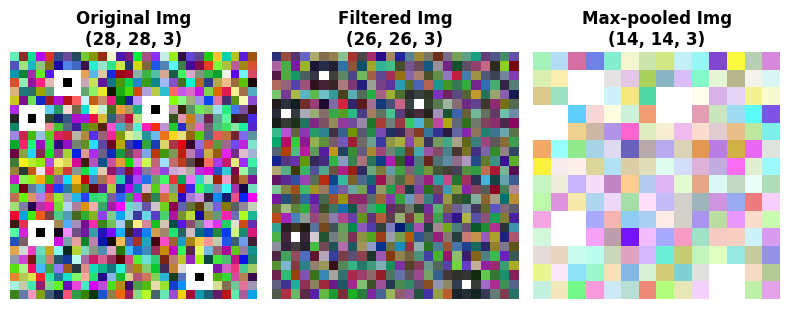

In [ ]:
np.random.seed(42)
img_array = np.random.random((28, 28, 3))

def create_eye(original_img, n=3):
    x_positions = np.random.randint(0, original_img.shape[1]-2, n)
    y_positions = np.random.randint(0, original_img.shape[0]-2, n)
    for i in range(n):
        original_img[x_positions[i]:x_positions[i]+3, y_positions[i]:y_positions[i]+3] = np.ones((3, 3, 3))
        original_img[x_positions[i]+1, y_positions[i]+1] = 0
    return original_img

# Put some random eyes in the image
img_array = create_eye(img_array, n=5)

# Prepare image for ConvLayer
img_array = img_array.transpose(2, 0, 1)  # Shape: (3, 28, 28)
img_array = img_array.reshape(1, 3, 28, 28)  # Shape: (1, 3, 28, 28)

# Eye detector kernel for RGB (3 output channels, 3 input channels)
eye_detector = np.array([[1, 1, 1],
                        [1, -8, 1],
                        [1, 1, 1]]) / 8  # Normalize
eye_filter = np.zeros((3, 3, 3, 3))
for i in range(3):  # Apply to each channel
    eye_filter[i, i, :, :] = eye_detector

# Apply ConvLayer
conv = Conv2D(input_channels=3, num_filters=3, filter_size=3, stride=1, padding=0)
conv.filters = eye_filter
filtered_img = conv.forward(img_array)  # Shape: (1, 3, 26, 26)

# Min-max scaling per channel
min_vals = filtered_img.min(axis=(0, 2, 3), keepdims=True)
max_vals = filtered_img.max(axis=(0, 2, 3), keepdims=True)
filtered_img = (filtered_img - min_vals) / (max_vals - min_vals + 1e-8)

# Apply MaxPooling
pool = MaxPool2D(pool_size=2, stride=2)
pooled_matrix = pool.forward(img_array)  # Shape: (1, 3, 14, 14)

# Reshape for visualization
img_array = img_array[0].transpose(1, 2, 0)  # Shape: (28, 28, 3)
filtered_img = filtered_img[0].transpose(1, 2, 0)  # Shape: (26, 26, 3)
pooled_matrix = pooled_matrix[0].transpose(1, 2, 0)  # Shape: (14, 14, 3)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(8, 5))
axes = axes.flatten()

images = [img_array, filtered_img, pooled_matrix]
titles = ['Original Img', 'Filtered Img', 'Max-pooled Img']

for ax, img, t in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(f'{t}\n{img.shape}', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

What this output is showing:

- **Original Image (28, 28, 3)**
  * **Description**: This is the starting point—a randomly generated RGB image with dimensions 28x28 pixels across three color channels (red, green, blue). The image features intriguing black-centered, white-surrounded shapes that resemble "eyes."
  * **Visual Insight**: Notice the distinct eye-like patterns scattered across the image. These serve as our test features, mimicking real-world objects we might want a neural network to detect.

---

- **Filtered Image (26, 26, 3)**
  * **Description**: The result of applying a custom 3x3 convolution kernel to the original image. The kernel is defined as:
  $$
  K_{3×3} = \begin{pmatrix}
  1 & 1 & 1 \\
  1 & -1 & 1 \\
  1 & 1 & 1 \\
  \end{pmatrix}
  $$
  * **How It Works**:
    - The central `-1` subtracts the pixel value at the center of the kernel’s window, while the surrounding `+1` values amplify the neighboring pixels. This accentuates edges or boundaries where intensity changes occur, making it ideal for detecting features like the edges of our "eyes."
    - Due to the kernel size (3x3) and lack of padding, the output dimensions shrink slightly from 28x28 to 26x26, losing edge pixels.
  * **Visual Insight**: Observe the bright spots—these highlight areas where the kernel detected significant changes, likely the edges of the eye-like shapes. The darker, more uniform tones elsewhere indicate regions with less variation. This demonstrates how the kernel selectively reacts to patterns it’s designed to emphasize!

---

- **Max-Pooled Image (14, 14, 3)**

  * **Description**: The outcome of applying max-pooling, which reduces the filtered image’s dimensions by half (from 26x26 to 14x14) across all three channels. Max-pooling selects the maximum value from each 2x2 non-overlapping region.
  * **How It Works**:
    - By taking the maximum value, max-pooling retains the most prominent features (e.g., the brightest pixels representing eye edges) while discarding less significant details.
    - This downsampling reduces computational load and helps prevent overfitting in neural networks.
  * **Visual Insight**: Compare this with the filtered image—note how the eye-like shapes’ positions and numbers are preserved, though the image is coarser. The reduction in size highlights the robustness of max-pooling in maintaining key features.

## **Fully Connected Layer**

Imagine a detective solving a case. After gathering clues—edges, shapes, or textures—from a crime scene (the image), they don’t need to know exactly where each clue was found. They just need to combine them to answer: “Who did it?” That’s what a **fully connected layer** does in a neural network. After convolutional and pooling layers shrink an image into small **feature maps** (not images anymore, but grids of key patterns like eyes or whiskers), we flatten these maps into a single list and use fully connected layers to make the final call—like deciding if the image shows a cat, dog, or person.

---

###**Effects of Flattening**
Convolutional layers find local patterns (e.g., an eye in one spot, a nose in another), and pooling shrinks these maps while keeping the strongest signals. By now, we’ve extracted the important features—say, “two eyes, one nose, whiskers.” The exact position of these features (top-left or bottom-right) doesn’t matter for the final question: “Is this a cat?” Flattening turns the feature maps into a single list (e.g., a 4x4 map becomes 16 numbers), and fully connected layers combine these clues to make a decision, like a detective weighing all evidence to name the suspect.

---

###**How it works:**
Each neuron in a fully connected layer connects to every value in the flattened list, learning how much each feature (like “whiskers”) contributes to the answer (e.g., “cat”). For example, if we have a 4x4x3 feature map (48 values after flattening), a fully connected layer with 10 neurons uses 480 weights plus biases to score possible classes (e.g., cat, dog, car). These scores often pass through a **softmax layer**, which turns them into probabilities—like saying “80% cat, 15% dog, 5% car.”

---

###**Backpropagation in Fully Connected Layers**:
The network calculates the error (how wrong the prediction was) and sends **blame** backward. Each weight adjusts slightly based on how much its feature influenced the mistake, making the layer better at combining clues next time.

**Quick Notes**:
- Fully connected layers can be stacked (e.g., multiple layers before softmax) to learn complex patterns.
- They use more parameters than convolutional layers, so we rely on convolution and pooling first to reduce data. This layer’s power is turning scattered clues into a clear answer!

In [ ]:
class Flatten(Layer):
    def forward(self, inp):
        self.inp_shape = inp.shape
        return inp.reshape(inp.shape[0], -1)

    def backward(self, up_grad):
        return up_grad.reshape(self.inp_shape)

class Linear(Layer):
    def __init__(self, input_features: int, output_features: int):
        np.random.seed(42)
        super().__init__()
        # He initialization: better scaling for deep networks
        self.w = np.random.randn(input_features, output_features) * np.sqrt(2 / input_features)
        self.b = np.zeros((1, output_features))
        self.dw = np.zeros_like(self.w)
        self.db = np.zeros_like(self.b)

    def forward(self, inp: np.ndarray) -> np.ndarray:
        """Perform the linear transformation: output = inp * W + b"""
        self.inp = inp
        self.out = np.dot(inp, self.w) + self.b
        return self.out

    def backward(self, up_grad: np.ndarray) -> np.ndarray:
        """Backpropagate the gradients through this layer."""
        # Compute gradients for weights and biases
        self.dw = np.dot(self.inp.T, up_grad)  # Gradient wrt weights
        self.db = np.sum(up_grad, axis=0, keepdims=True)  # Gradient wrt biases
        # Compute gradient to propagate back (downstream)
        down_grad = np.dot(up_grad, self.w.T)
        return down_grad

    def step(self, lr: float) -> None:
        """Update the weights and biases using the gradients."""
        self.w -= lr * self.dw
        self.b -= lr * self.db

class ReLU(Layer):
    def forward(self, inp):
        self.inp = inp
        self.out = np.maximum(0, inp)
        return self.out

    def backward(self, up_grad):
        return up_grad * (self.inp > 0)

class Softmax(Layer):
    def forward(self, inp):
        exp_X = np.exp(inp - np.max(inp, axis=1, keepdims=True))
        self.out = exp_X / np.sum(exp_X, axis=1, keepdims=True)
        return self.out

    def backward(self, up_grad):
        down_grad = np.empty_like(up_grad)
        for i in range(up_grad.shape[0]):
            single_out = self.out[i].reshape(-1, 1)
            jacobian = np.diagflat(single_out) - np.dot(single_out, single_out.T)
            down_grad[i] = np.dot(jacobian, up_grad[i])
        return down_grad

class CrossEntropyLoss:
    def __init__(self):
        self.pred = None
        self.target = None
        self.loss = None

    def compute_loss(self, pred, target):
        self.pred = pred
        self.target = target

        # Clip predictions to avoid log(0)
        clipped_pred = np.clip(pred, 1e-12, 1.0)
        return -np.mean(np.sum(target * np.log(clipped_pred), axis=1))

    def backward(self):
        return - self.target / self.pred / self.pred.shape[0]

class CNN:
    def __init__(self, layers, loss_fn):
        self.layers = layers
        self.loss_fn = loss_fn

    def forward(self, inp):
        for layer in self.layers:
            inp = layer.forward(inp)
        return inp

    def loss(self, pred, target):
        return self.loss_fn.compute_loss(pred, target)

    def backward(self):
        up_grad = self.loss_fn.backward()
        for layer in reversed(self.layers):
            up_grad = layer.backward(up_grad)

    def step(self, lr):
        for layer in self.layers:
            layer.step(lr)

    def train(self, X, y, X_test, y_test, epochs, batch_size, learning_rate = 0.01):
        train_losses, test_accuracies = np.empty((2, epochs))
        for epoch in range(epochs):
            running_loss = 0.0
            for i in range(0, len(X), batch_size):
                X_batch = X[i:i + batch_size]
                y_batch = y[i:i + batch_size]
                pred = self.forward(X_batch)
                running_loss += self.loss(pred, y_batch) * batch_size
                self.backward()
                self.step(lr=learning_rate)
            running_loss /= len(X)
            test_pred = self.forward(X_test)
            test_accuracy = 100 * (np.sum(np.argmax(test_pred, axis=1) == np.argmax(y_test, axis=1))) / len(X_test)
            train_losses[epoch] = running_loss
            test_accuracies[epoch] = test_accuracy
            print(f'Epoch {(epoch + 1):>02} | Training Loss: {running_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
        return train_losses, test_accuracies

##**Application on MNIST**

Our earlier exploration on MNIST Dataset with a fully connected neural network equipped with `Batch Normalization` and optimized by `Adam` (MLPBN) utilized this architecture:

```python
layers = [
    LinearAdamBN(784, 100),  # 784 input features
    ReLU(),
    LinearAdamBN(100, 10),
    Softmax()
]
mlp = MLPBN(layers, CrossEntropyLoss())
bn_loss_history, bn_accuracy_history = mlp.train(X_train, y_train, X_test, y_test, epochs=40, lr=0.1)
```

For MNIST images, flattened to $28×28 = 784$ features, the first layer linked these to $100$ neurons, requiring $784×100 = 78,400$ weights, $100$ biases, and $100$ BatchNorm parameters $(γ, β)$, totaling $78,600$ parameters. The second layer connected $100$ neurons to $10$ outputs, needing $1,000$ weights, $10$ biases, and $10$ BatchNorm parameters, for $1,020$ parameters. Overall, the model had **$79,620$ parameters**, consuming approximately:

$$
\frac{79,620 × 4 \text { bytes}}{1024} = 311.01 \text{ KB}
$$

Despite a low loss, the accuracy stabilized at $~97.8\%$, and the high parameter count heightened the risk of overfitting and demanded significant memory.

Now, behold the elegance of our convolutional neural network (CNN) below:

Parameter count:
- **First Conv2D**: 16 filters, each with $7×7×1 = 49$ weights and 1 bias, yield $16 × 50 =$ $800$ parameters.
- **Second Conv2D**: 16 filters, each with $3×3×16 = 144$ weights and 1 bias, yield $16 × 145 = 2,320$ parameters.
- **Linear**: $64×10 = 640$ weights plus 10 biases = $650$ parameters.
- **Total**: $800 + 2,320 + 650 = 3,770$ parameters.

This lean architecture requires only:

$$
\frac {3,770 × 4 \text{ bytes}} {1024} \approx 14.73 \text { KB}
$$

A remarkable $21$-fold reduction compared to the MLP’s $311$ KB. With a stellar test accuracy of $98.10\%$, surpassing the MLP’s record, the CNN showcases its prowess. By leveraging weight sharing, it efficiently captures spatial patterns with fewer parameters, significantly reducing overfitting risk and storage demands while achieving superior performance.

In [ ]:
def onehot_encoder(y, num_labels):
    one_hot = np.zeros(shape=(y.size, num_labels), dtype=int)
    one_hot[np.arange(y.size), y] = 1
    return one_hot

def plot_results(train_losses, test_accuracies):
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses) + 1), train_losses, color='red')
    plt.title('Train Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, color='green')
    plt.title('Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid()
    plt.show()

def plot_tests(model, X_test, y_test, class_names=None):
    np.random.seed(42)

    # Compute predictions for all X_test
    predictions = model.forward(X_test)  # Shape: (n, 10)
    predictions = np.argmax(predictions, axis=1)  # Shape: (n,)

    # Handle one-hot or integer y_test
    y_true = np.argmax(y_test, axis=1) if y_test.ndim == 2 else y_test

    # Calculate F1-score and confusion matrix
    f1 = f1_score(y_true, predictions, average='macro')
    cm = confusion_matrix(y_true, predictions)

    # Plot confusion matrix
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names if class_names else np.arange(10)).plot(cmap='Blues')
    plt.title(f'F1-Score: {f1:.6f}', fontweight='bold')
    if class_names:
        plt.xticks(rotation = 45)
    plt.show()

    # Randomly select 15 samples
    indices = np.random.choice(X_test.shape[0], 30, replace=False)
    X_samples = X_test[indices]  # Shape: (15, channels, h, w) or (30, features)
    y_samples = y_true[indices]  # Shape: (15,)
    pred_samples = predictions[indices]  # Shape: (15,)

    # Create 3x5 subplot grid
    fig, axes = plt.subplots(3, 10, figsize=(20, 9))
    axes = axes.flatten()

    # Plot each sample
    for i, ax in enumerate(axes):
        # Reshape image for visualization (grayscale, 28x28)
        if X_samples.shape[1] == 1:  # CNN input: (15, 1, 28, 28)
            img = X_samples[i, 0]
        else:  # MLP input: (15, 784)
            img = X_samples[i].reshape(28, 28)

        # Get real and predicted labels
        real = class_names[y_samples[i]] if class_names else y_samples[i]
        pred = class_names[pred_samples[i]] if class_names else pred_samples[i]

        # Set title color: red if incorrect, black if correct
        title_color = 'red' if pred_samples[i] != y_samples[i] else 'green'

        # Plot image and set title
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Real: {real}\nPred: {pred}', color=title_color, fontsize=18)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Load and preprocess MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train =((X_train.astype('float32') / 255.0) - 0.5) * 2
X_test = ((X_test.astype('float32') / 255.0) - 0.5) * 2
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)
y_train = onehot_encoder(y_train, 10)
y_test = onehot_encoder(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Epoch 01 | Training Loss: 0.3674, Test Accuracy: 94.44%
Epoch 02 | Training Loss: 0.1408, Test Accuracy: 96.29%
Epoch 03 | Training Loss: 0.1087, Test Accuracy: 96.93%
Epoch 04 | Training Loss: 0.0924, Test Accuracy: 97.33%
Epoch 05 | Training Loss: 0.0821, Test Accuracy: 97.67%
Epoch 06 | Training Loss: 0.0746, Test Accuracy: 97.93%
Epoch 07 | Training Loss: 0.0690, Test Accuracy: 97.97%
Epoch 08 | Training Loss: 0.0644, Test Accuracy: 98.10%
Epoch 09 | Training Loss: 0.0605, Test Accuracy: 98.10%
Epoch 10 | Training Loss: 0.0573, Test Accuracy: 98.10%


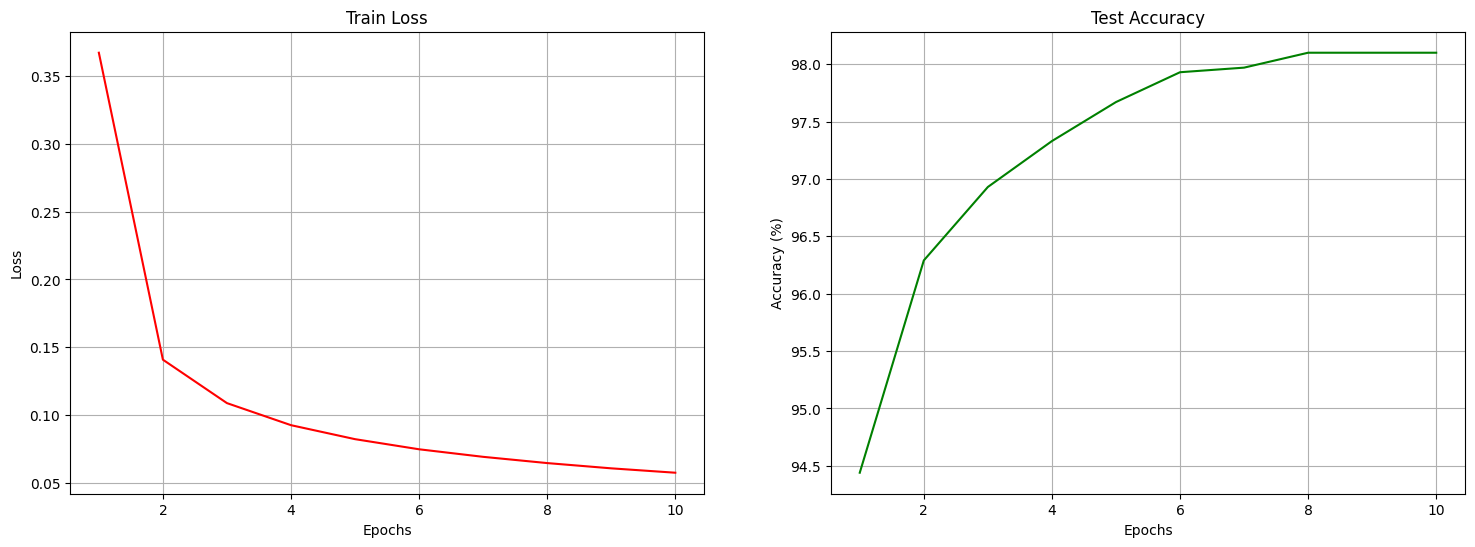

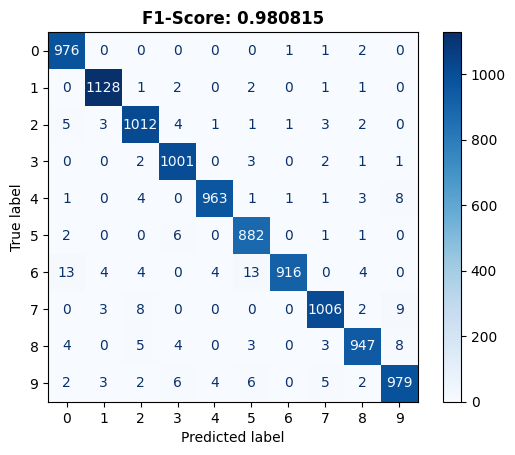

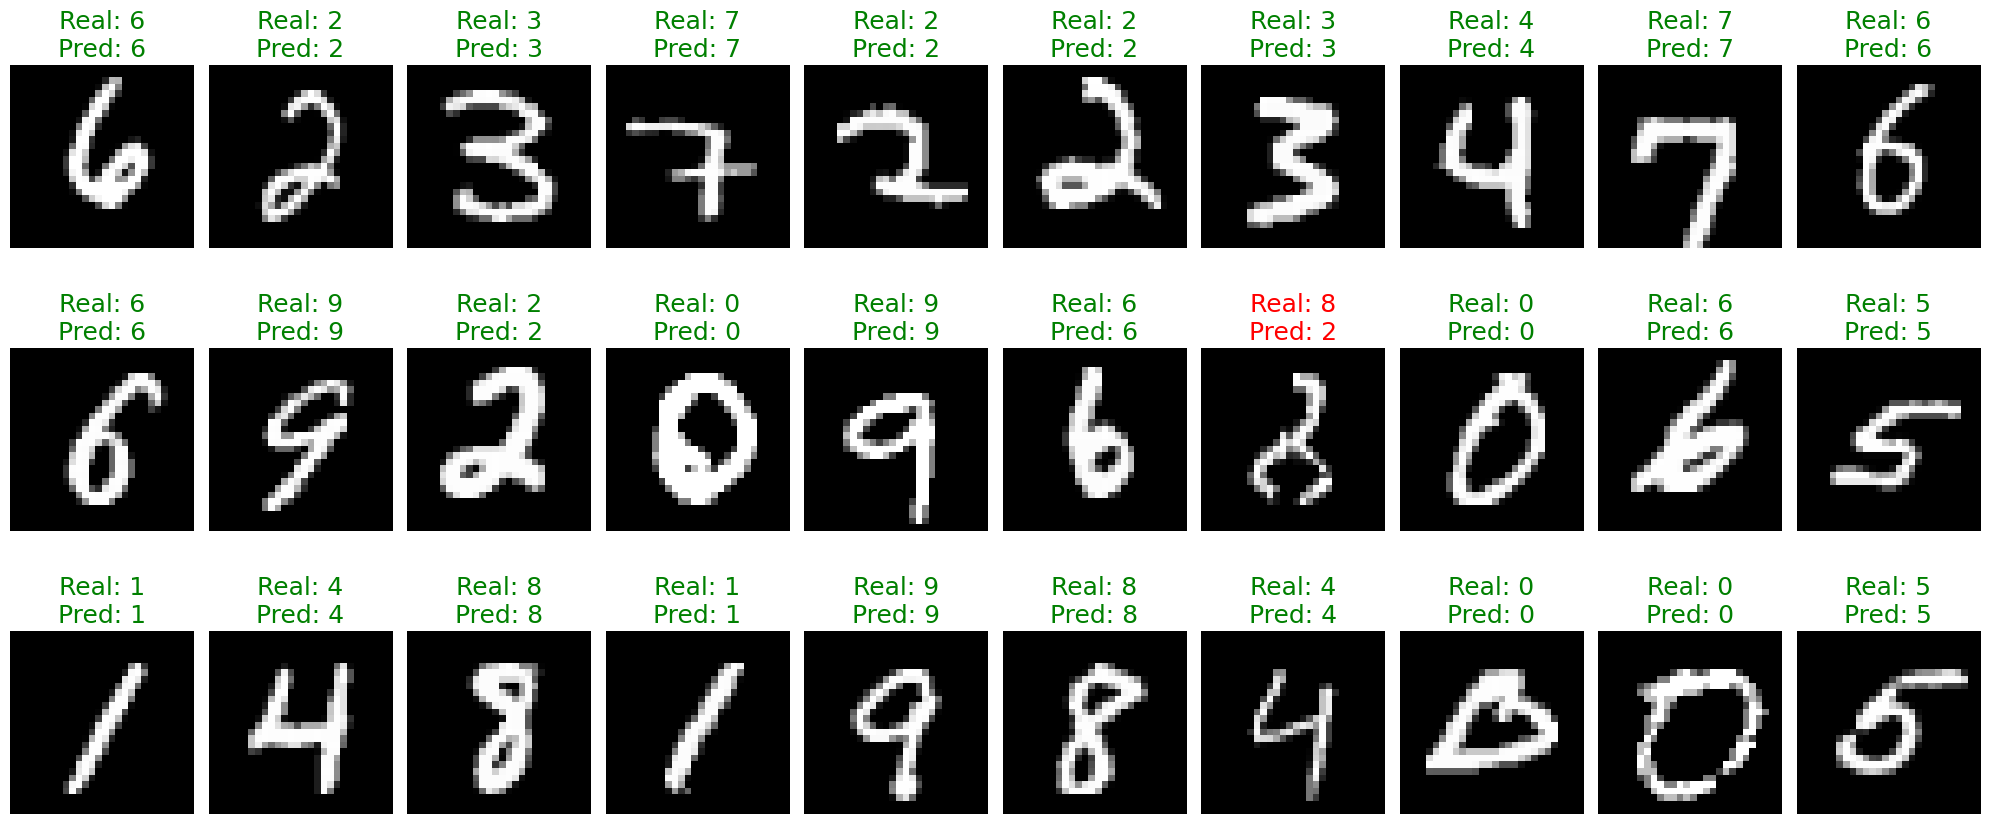

In [ ]:
# Define the layers of the neural network
layers = [
    Conv2D(input_channels = 1, num_filters = 16, filter_size = 7, stride = 3),   # Output shape (batch_size, 16, 8, 8)
    ReLU(),                                                                      # Output shape (no change)
    MaxPool2D(),                                                                 # Output shape (batch_size, 16, 4, 4)
    Conv2D(input_channels = 16, num_filters = 16, filter_size = 3, padding = 1), # Output shape (batch_size, 16, 4, 4)
    ReLU(),                                                                      # Output shape (no change)
    MaxPool2D(),                                                                 # Output shape (batch_size, 16, 2, 2)
    Flatten(),                                                                   # Output shape (batch_size, 64)
    Linear(input_features = 64, output_features = 10),                           # Output shape (batch_size, 10)
    Softmax()                                                                    # Output shape (no change)
]

# Initialize and train
cnn = CNN(layers, CrossEntropyLoss())
results = cnn.train(X_train, y_train, X_test, y_test, epochs = 10, batch_size = 64, learning_rate = 0.05)

plot_results(*results)
plot_tests(cnn, X_test, y_test)

## **Application on Fashion-MNIST**

The **Fashion-MNIST dataset** consists of *70,000 grayscale images* of clothing items, each with size **28×28 pixels**. It contains **10 categories** such as shirts, trousers, sneakers, and coats, designed as a more challenging alternative to the classic MNIST digits.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C00/fashion_mnist.png" width="600">
  <h6>Figure: Classes in Fashion-MNIST dataset</h6>
</div>

**Image Credit:** [Original Website](https://www.researchgate.net/figure/The-FashionMNIST-dataset-consists-of-10-classes-of-monochrome-clothing-items-and-is_fig1_373046669)

Here, we applied the **same simple CNN architecture** that had previously worked very well on MNIST digits. But this time, the performance dropped significantly. Why?  
Because while digits are made up of simple strokes and curves, **fashion items contain far richer textures, shapes, and fine details**. A shallow CNN can easily capture the features of digits, but it struggles to perceive the subtler patterns of shirts, dresses, and sandals.

Interestingly, even this weak model reveals the **inductive bias** of CNNs. From the confusion matrix, we can see that the model often confused **shirts, T-shirts, and coats**—a mistake we humans also find understandable since these categories share overlapping features. On the other hand, **boots were not confused with shirts at all**, except occasionally with sandals or sneakers, which again makes sense because their outlines and textures are somewhat related.  

And this is important: **not all mistakes are equal.**  
It is much less severe if our model mistakenly thinks a **shirt is a T-shirt** than if it classifies a **shirt as a pair of shoes**. Imagine a real-world application: recommending clothes in an online shop. Recommending a T-shirt instead of a shirt is tolerable, but recommending shoes instead could completely break the user’s trust.  

This is precisely why CNNs shine compared to dense networks:  
- A dense model might absurdly classify a sandal as a T-shirt, because to it, images are just flattened vectors of numbers.  
- A CNN, however, looks at **local patterns**, so its mistakes are usually “reasonable.”  

Think of it like a child learning names of animal: mistaking a **leopard for a tiger** is understandable, but mistaking it for a **penguin** would be absurd. CNNs inherit this same kind of natural bias, making their errors more meaningful—and often less harmful—than those of dense networks.

In [ ]:
class_names = {0: 'T-shirt', 1: 'Trouser', 2: 'Pullover',
               3: 'Dress', 4: 'Coat', 5:  'Sandal', 6: 'Shirt',
               7: 'Sneaker', 8: 'Bag', 9: 'Boot'}
n_classes = 10

# Load Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Preprocess: Normalize, reshape to (batch, channels=1, height, width), one-hot labels
X_train = ((X_train.astype('float32') / 255.0) - 0.5) * 2
X_test = ((X_test.astype('float32') / 255.0) - 0.5) * 2
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)
y_train = onehot_encoder(y_train, n_classes)
y_test = onehot_encoder(y_test, n_classes)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Epoch 01 | Training Loss: 0.9148, Test Accuracy: 76.61%
Epoch 02 | Training Loss: 0.5856, Test Accuracy: 79.90%
Epoch 03 | Training Loss: 0.5248, Test Accuracy: 81.53%
Epoch 04 | Training Loss: 0.4892, Test Accuracy: 82.37%
Epoch 05 | Training Loss: 0.4646, Test Accuracy: 82.96%
Epoch 06 | Training Loss: 0.4462, Test Accuracy: 83.63%
Epoch 07 | Training Loss: 0.4318, Test Accuracy: 83.95%
Epoch 08 | Training Loss: 0.4202, Test Accuracy: 84.24%
Epoch 09 | Training Loss: 0.4106, Test Accuracy: 84.55%
Epoch 10 | Training Loss: 0.4024, Test Accuracy: 84.68%


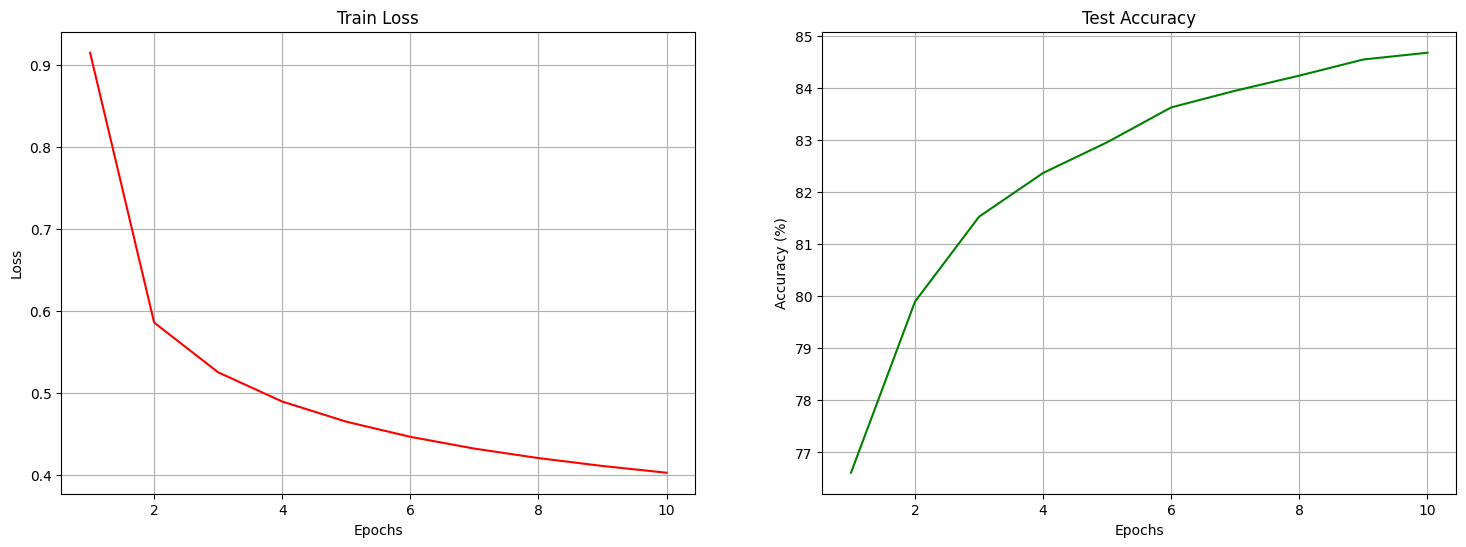

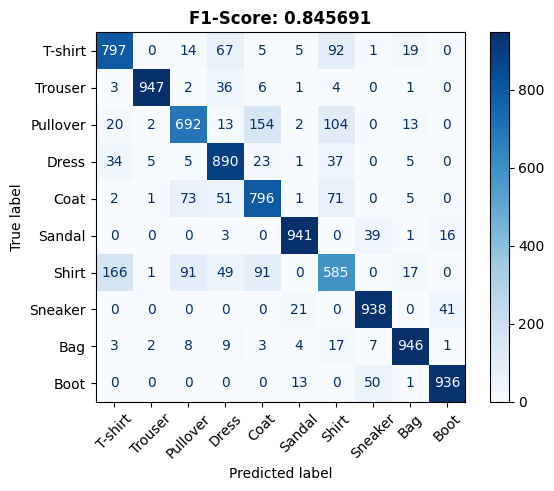

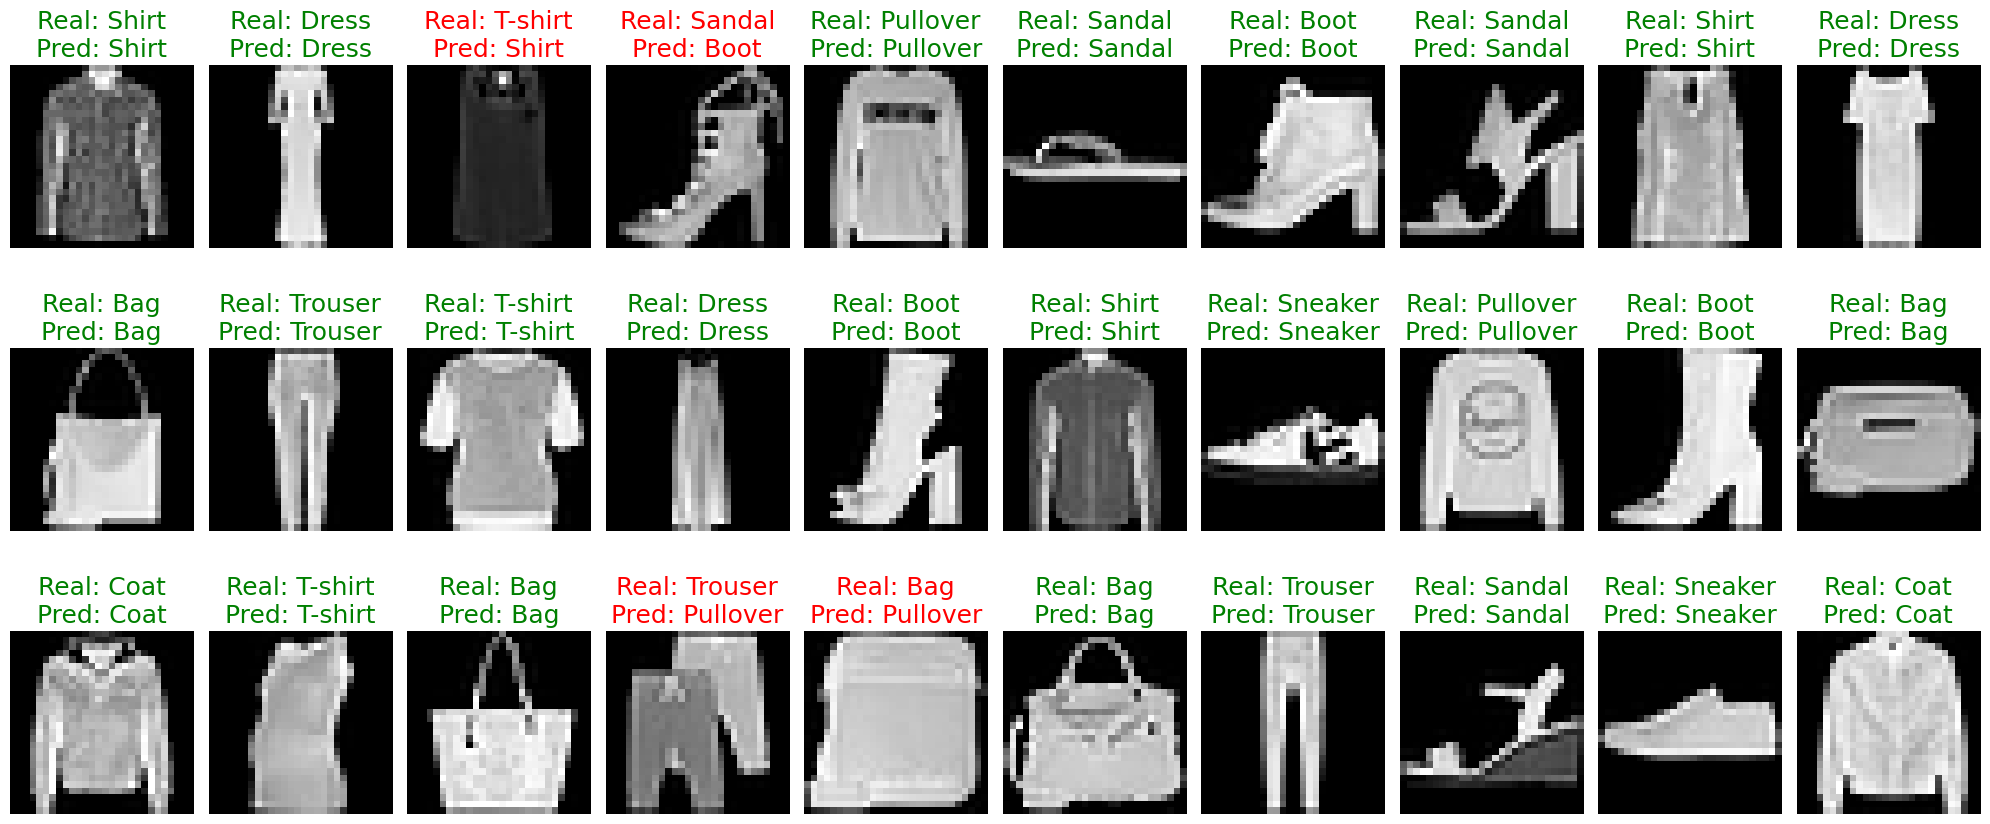

In [ ]:
# Define the layers of the neural network
layers = [
    Conv2D(input_channels = 1, num_filters = 16, filter_size = 7, stride = 3),   # Output shape (batch_size, 16, 8, 8)
    ReLU(),                                                                      # Output shape (no change)
    MaxPool2D(),                                                                 # Output shape (batch_size, 16, 4, 4)
    Conv2D(input_channels = 16, num_filters = 16, filter_size = 3, padding = 1), # Output shape (batch_size, 16, 4, 4)
    ReLU(),                                                                      # Output shape (no change)
    MaxPool2D(),                                                                 # Output shape (batch_size, 16, 2, 2)
    Flatten(),                                                                   # Output shape (batch_size, 64)
    Linear(input_features = 64, output_features = n_classes),                    # Output shape (batch_size, 10)
    Softmax()                                                                    # Output shape (no change)
]

# Initialize and train
cnn = CNN(layers, CrossEntropyLoss())
results = cnn.train(X_train, y_train, X_test, y_test, epochs = 10, batch_size = 64, learning_rate = 0.01)

plot_results(*results)
plot_tests(cnn, X_test, y_test, list(class_names.values())[:n_classes])

##**Closing This Chapter**

In this chapter, we built a foundation for **Convolutional Neural Networks** by stacking its three essential building blocks:  
- **Convolution layers**, to detect local features,  
- **Pooling layers**, to refine and compress them,  
- **Flattening & fully connected layers**, to finally make predictions.  

Together, these gave us a *visual substitute* for the **dense neural networks** we studied in the previous section. The real magic here is the **inductive bias** CNNs bring: they respect the spatial structure of images, allowing models to see *shapes, edges, and patterns*—not just numbers. This small step has taken us from simple lists of pixels to **networks that can “see.”**

---

### **What’s Next?**

We now move from a simple CNN to the:

> **Deep CNN Architectures**

- **AlexNet**, the breakthrough model that put CNNs on the global stage.  
- **ResNet**, a revolutionary design that unlocked the possibility of training very deep networks.  

These architectures didn’t just improve accuracy; they **changed how we think about neural networks**—showing us why depth matters, how residual connections opened new doors, and why modern AI is so powerful that isn't even comparable to human intelligence.